In [1]:
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader
from dl_project import load_dataset, image_augmentation

RUN_TESTS = True

In [2]:
# CUDA settings
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# torch.set_default_device(device)
# set default dtype to control memory usage
dtype = torch.float16
dtype = torch.float32
# torch.cuda.setdetault_tensor_type(torch.cuda.FloatTensor)

# torch.cuda.set_per_process_memory_fraction(0.9, device=device) # fraction of GPU memory to use
# print(torch.get_num_threads())
# torch.set_num_threads(6)

Number of images: 65


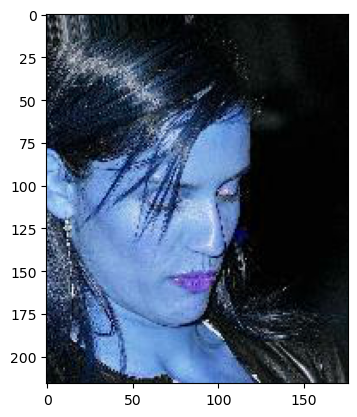

In [3]:
# load the dataset

# helper function to convert GPU tensor to image on CPU
def tensor_to_image(x, permute=True):
    if len(x.shape) == 4:
        x = x[0]  # take first image in batch
    if permute:
        x = x.permute(1, 2, 0)
    x = x.to(torch.float32).cpu().detach().numpy()
    x = np.clip(x, 0, 1)  # clip image to valid color range
    return x


# helper function to move batch to GPU before the dataloader returns it
def collate_fn(batch):
    batch = [item.to(device) for item in batch]
    return torch.stack(batch)


# UNet architecture requires width and height to be a multiple of 2^depth
def crop_images_to_multiple_of_n(images, n=8):
    # determine crop area, remove excess pixels from borders
    _, h, w = images[0].shape
    h_to_remove, w_to_remove = h % n, w % n
    start_h, start_w = h_to_remove // 2, w_to_remove // 2
    end_h, end_w = h - h_to_remove // 2, w - w_to_remove // 2

    # crop images
    cropped_images = []
    for image in images:
        cropped_images.append(image[:, start_h:end_h, start_w:end_w])
    return cropped_images

# load images
batch_size = 2  # for testing
all_images = load_dataset()
all_images = crop_images_to_multiple_of_n(all_images)
mini_dataset = all_images[:9] # not a multiple of batch_size for testing
# todo pin_memory=True
mini_dataloader = DataLoader(mini_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
print(f"Number of images: {len(all_images)}")

# display first image
image_batch = next(iter(mini_dataloader))
plt.imshow(tensor_to_image(image_batch[0]))
plt.show()

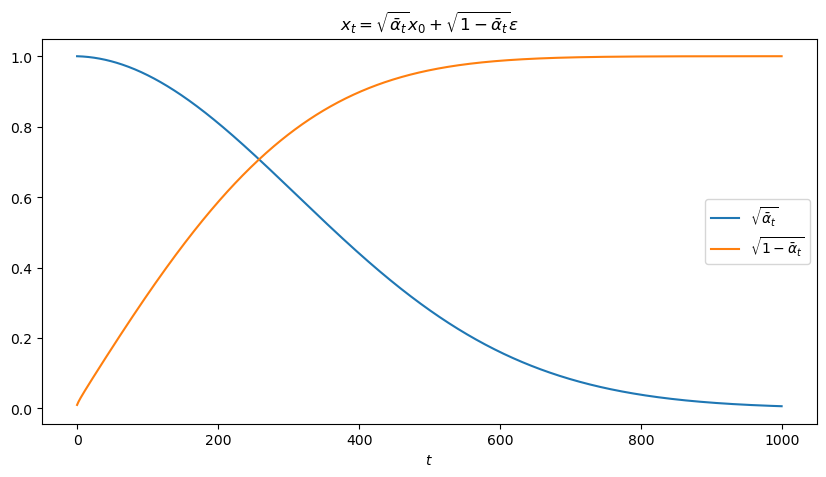

In [4]:
# Noise schedule defines how much noise is added at each time step
class Schedule:
    def __init__(self, beta_1, beta_T, T, type="linear"):
        assert 0 < beta_1 < beta_T < 1, f"Invalid beta values: {beta_1}, {beta_T}"
        if type == "linear":
            beta = torch.linspace(beta_1, beta_T, T)
            self.alpha = 1 - beta
        elif type == "cosine":
            # ? is this correct?
            t = torch.linspace(0, T, T)
            self.alpha = torch.cos(t * (np.pi / 2 / T)) ** 2
        else:
            raise ValueError(f"Unknown schedule type: {type}")

        self.T = T
        self.alpha_bar = torch.cumprod(self.alpha, 0)  # product of all elements in alpha from 1 to t
        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar)  # first term of noise equation
        self.sqrt_1_minus_alpha_bar = torch.sqrt(1 - self.alpha_bar)  # second term of noise equation
        self.one_over_sqrt_alpha = 1 / torch.sqrt(self.alpha)  # first term of sampling equation
        self.beta_over_sqrt_1_minus_alpha_bar = beta / self.sqrt_1_minus_alpha_bar  # second term of sampling equation

    def to(self, device=device):
        self.alpha = self.alpha.to(device)
        self.alpha_bar = self.alpha_bar.to(device)
        self.sqrt_alpha_bar = self.sqrt_alpha_bar.to(device)
        self.sqrt_1_minus_alpha_bar = self.sqrt_1_minus_alpha_bar.to(device)
        self.one_over_sqrt_alpha = self.one_over_sqrt_alpha.to(device)
        self.beta_over_sqrt_1_minus_alpha_bar = self.beta_over_sqrt_1_minus_alpha_bar.to(device)
        return self


# typical values
T = 1000
beta_1 = 0.0001
beta_T = 0.02

# test schedules by comparing it with the example in P12.ipynb
if RUN_TESTS:
    schedule = Schedule(1e-4, 0.02, 1000)
    sqrt_alpha_bar = schedule.sqrt_alpha_bar
    sqrt_one_minus_alpha_bar = schedule.sqrt_1_minus_alpha_bar

    plt.figure(figsize=(10, 5))
    plt.title(r"$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon$")
    plt.xlabel("$t$")
    plt.plot(sqrt_alpha_bar.cpu(), label=r"$\sqrt{\bar{\alpha}_t}$")
    plt.plot(sqrt_one_minus_alpha_bar.cpu(), label=r"$\sqrt{1-\bar{\alpha}_t}$")
    plt.legend()
    plt.show()

In [5]:
# UNet building blocks
class ResBlock(nn.Module):
    def __init__(self, num_channels, time_embedding_dim, dropout_rate=0.5):
        super().__init__()
        self.relu = nn.ReLU()
        # ! only use primitives (batchnorm, conv2d, dropout)
        self.norm1 = nn.BatchNorm2d(num_features=num_channels)
        self.norm2 = nn.BatchNorm2d(num_features=num_channels)
        self.conv1 = nn.Conv2d(in_channels=num_channels, out_channels=num_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=num_channels, out_channels=num_channels, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(p=dropout_rate)
        # project time embedding to desired channel dimension,
        # since each resblock requires an embedding of the same dimension as the input
        # todo fix time embed dim => should match x dim
        self.time_mlp = nn.Linear(time_embedding_dim, num_channels)

    def forward(self, x, time_embedding):
        x = x + self.time_mlp(time_embedding).unsqueeze(-1).unsqueeze(-1)
        residual = x
        x = self.conv1(self.relu(self.norm1(x)))
        x = self.dropout(x)
        x = self.conv2(self.relu(self.norm2(x)))
        return x + residual


class AttentionBlock(nn.Module):
    def __init__(self, embedding_dim, num_heads, dropout_rate=0.5):
        super().__init__()
        # copied from assignment 3 and modified
        self.num_heads = num_heads  # Number of attention heads
        self.embedding_dim = embedding_dim  # Embedding dimensionality

        # Maps embedding into Q, K, V. We'll use one layer to generate these matrices for all heads at once.
        self.qkv_map = nn.Linear(embedding_dim, 3 * embedding_dim)

        # After performing attention for each head individually, we concat the results
        # and feed them through this linear layer.
        self.final_projection = nn.Linear(embedding_dim, embedding_dim)
        self.final_dropout = nn.Dropout(dropout_rate)  # regularization

    # todo simplify reshaping procedure
    def forward(self, x):
        H, W = x.shape[2:]
        x = x.flatten(2, 3).permute(0, 2, 1)  # reshape image to sequence (B, C, H, W) => (B, T, C)
        B, T, C = x.shape  # B: batch size, T: sequence length, C: embedding dimension
        d_k = C // self.num_heads  # dimension of q/k/v vectors

        # compute queries, keys, values with a single projection, split up and reshape
        qkv = self.qkv_map(x)
        Q, K, V = torch.chunk(qkv, 3, dim=-1)
        Q = Q.reshape(B, T, self.num_heads, d_k).transpose(1, 2)
        K = K.reshape(B, T, self.num_heads, d_k).transpose(1, 2)
        V = V.reshape(B, T, self.num_heads, d_k).transpose(1, 2)

        for M in [Q, K, V]:
            assert M.shape == (
                B,
                self.num_heads,
                T,
                d_k,
            ), f"Expected shape (B, self.n_head, T, d_k), but got {M.shape}"

        # compute similarity between queries and keys
        # compute attention weights based on similarity
        # update embeddings with weighted values
        S = Q @ K.transpose(-2, -1) / np.sqrt(d_k)
        A = F.softmax(S, dim=-1)
        out = A @ V

        # rearrange back to (B, C, H, W) shape
        out = out.transpose(1, 2).reshape(B, T, C)
        out = self.final_dropout(self.final_projection(out))
        out = out.reshape(B, C, H, W)
        return out


# 2 ResBlocks with an optional AttentionBlock in between followed by a final Up/Downsampling block
class UNetLayer(nn.Module):
    def __init__(self, type, num_channels, time_embedding_dim, num_heads=0):
        super().__init__()
        self.type = type
        self.res1 = ResBlock(num_channels, time_embedding_dim)
        self.res2 = ResBlock(num_channels, time_embedding_dim)
        self.num_heads = num_heads
        # if num_heads:
        #    self.attention = AttentionBlock(num_channels, num_heads=num_heads)

        if type == "down":
            self.conv = nn.Conv2d(num_channels, num_channels * 2, kernel_size=3, stride=2, padding=1)
        elif type == "up":
            self.conv = nn.ConvTranspose2d(
                num_channels, num_channels // 2, kernel_size=3, stride=2, padding=1, output_padding=1
            )
        else:
            raise ValueError(f"Unknown layer type: {type}")

    def forward(self, x, time_embeddings):
        x = self.res1(x, time_embeddings)
        # todo add back attention
        # if self.num_heads:
        #    x = self.attention(x)
        x = self.res2(x, time_embeddings)
        if self.type == "down":
            return self.conv(x), x  # downsampled version + residual
        return self.conv(x)  # upsampled versions


# generate time embeddings for UNet using a MLP
# todo experiment with sinusoidal embeddings and other methods
class MLPTimeEmbedding(nn.Module):
    def __init__(self, T, embedding_dim):
        super().__init__()
        self.T = T
        self.mlp = nn.Sequential(
            nn.Linear(1, embedding_dim),
            nn.ReLU(),
        )

    def forward(self, t):
        t.to(torch.float16)
        assert (t >= 0).all() and (t <= self.T).all()
        t = t / self.T  # normalize to [0, 1]
        return self.mlp(t.unsqueeze(-1))

In [6]:
# generate time embeddings for UNet using a MLP
# todo experiment with sinusoidal embeddings and other methods
class MLPTimeEmbedding(nn.Module):
    def __init__(self, T, embedding_dim):
        super().__init__()
        self.T = T
        self.mlp = nn.Sequential(
            nn.Linear(1, embedding_dim),
            nn.ReLU(),
        )

    def forward(self, t):
        t = t.to(dtype).unsqueeze(-1)  # convert int to float
        assert (t >= 0).all() and (t <= self.T).all()
        t = t / self.T  # normalize to [0, 1]
        time_embedding = self.mlp(t)
        assert torch.isfinite(time_embedding).all(), f"Found NaNs or Infs in time embedding"
        return time_embedding


if RUN_TESTS:
    # test time embedding for indices 0 to 10000
    dim = 128
    T = 1_000
    mlp = MLPTimeEmbedding(T, dim).to(device)
    for t in range(T):
        t_vector = torch.randint(0, T, (batch_size,)).to(device)  # dont bother asking why
        emb = mlp(t_vector)
        assert emb.shape == (batch_size, dim), f"Expected shape ({batch_size},128), but got {emb.shape}"
        assert torch.isfinite(emb).all(), f"Found NaNs or Infs in time embedding at t={t}"
        assert emb.dtype == dtype, f"Expected dtype {dtype}, but got {emb.dtype}"

In [7]:
# UNet model which takes a noisy image and a time index and predicts the variance of the noise
class UNet(nn.Module):
    def __init__(
        self,
        T,
        depth=3,
        initial_channels=64,
        time_embedding_dim=32,
        color_spectrum=3,
    ):
        super(UNet, self).__init__()

        # dynamic channel calculation based on depth
        # downsampling reduces the image size by a factor of 2 but doubles the number of channels
        down_channels = []
        for i in range(depth):
            down_channels.append(initial_channels * (2**i))

        # upsampling halves the number of channels but doubles the image size
        up_channels = [down_channels[-1] * 2]  # bottleneck without skip connection
        for i in range(depth - 1, 0, -1):
            up_channels.append(down_channels[i] + up_channels[-1] // 2)
        final_channels = up_channels[-1] // 2 + down_channels[0]

        # initial convolution to map input to desired number of initial channels
        self.conv1 = nn.Conv2d(color_spectrum, down_channels[0], kernel_size=3, padding=1)

        # down layers which produce skip connections
        self.down_layers = nn.ModuleList(
            [
                UNetLayer("down", down_channels[0], time_embedding_dim),
                UNetLayer("down", down_channels[1], time_embedding_dim, num_heads=8),
                UNetLayer("down", down_channels[2], time_embedding_dim),
            ]
        )
        self.bottleneck = UNetLayer("up", up_channels[0], time_embedding_dim)
        # up layers which receive skip connections
        self.up_layers = nn.ModuleList(
            [
                UNetLayer("up", up_channels[1], time_embedding_dim),
                UNetLayer("up", up_channels[2], time_embedding_dim, num_heads=8),
            ]
        )

        # convolution to half the number of channels, also receives skip connection
        self.conv2 = nn.Conv2d(final_channels, final_channels // 2, kernel_size=3, padding=1)
        # final layer to map back to RGB
        self.conv3 = nn.Conv2d(final_channels // 2, color_spectrum, kernel_size=3, padding=1)

        self.activation = nn.ReLU()
        self.time_embedding = MLPTimeEmbedding(T, time_embedding_dim)

    def forward(self, x, t):
        H, W = x.shape[2:]
        depth = len(self.down_layers)
        assert H % (2**depth) == 0 and W % (2**depth) == 0, "Image size must be divisible by 2^depth"

        time_embedding = self.time_embedding(t)
        x = self.activation(self.conv1(x))

        # downsample and store intermediates for skip connections
        residuals = []
        for down in self.down_layers:
            x, r = down(x, time_embedding)
            residuals.append(r)

        # bottleneck without skip connection
        x = self.bottleneck(x, time_embedding)

        # upsample and concatenate skip connections
        residuals = residuals[::-1]  # add residuals in reverse order
        for i in range(len(self.up_layers)):
            x = torch.cat([x, residuals[i]], dim=1)
            x = self.up_layers[i](x, time_embedding)

        # final convolutions back to RGB
        x = torch.cat([x, residuals[-1]], dim=1)  # final residual
        x = self.activation(self.conv2(x))
        x = self.conv3(x)
        return x


# test UNet
if RUN_TESTS:
    unet = UNet(T).to(device)
    image_batch = torch.randn(batch_size, 3, 64, 64).to(device)
    t = torch.randint(0, T, (batch_size,)).to(device)
    output = unet(image_batch, t)
    assert output.shape == image_batch.shape, f"Expected output shape {image_batch.shape}, but got {output.shape}"
    assert torch.isfinite(output).all(), "Found NaNs or Infs in output"

In [8]:
class DDPM(nn.Module):
    sigma_t_constant = {"strategy": "constant", "constant": 0.05}
    sigma_t_linear = {"strategy": "linear", "min": 0.01, "max": 0.1}
    sigma_t_cosine = {"strategy": "cosine", "min": 0.01, "max": 0.1}

    # todo explore register_buffer
    # todo experiment with torch.compile
    def __init__(self, schedule, sigma_t_strategy=sigma_t_constant):
        super(DDPM, self).__init__()
        self.schedule = schedule.to(device)  # defines how much noise is added at each time step
        self.noise_predictor = UNet(schedule.T)  # predicts noise given a noisy image and a time t
        self.sigma_t_strategy = sigma_t_strategy  # strategy for noise which is added back during sampling
        self.losses = []  # store training losses
        self.to(device)

    # adds noise to the input image
    def forward_diffusion(self, x, t):
        epsilon = torch.randn(x.shape).to(device)  # add random noise
        alpha_bar_t = self.schedule.alpha_bar[t].view(-1, 1, 1, 1)  # broadcast to batch size
        sqrt_1_minus_alpha_bar_t = self.schedule.sqrt_1_minus_alpha_bar[t].view(-1, 1, 1, 1)
        return alpha_bar_t * x + sqrt_1_minus_alpha_bar_t * epsilon, epsilon

    # generates images from noise
    def generate_images(self, shape, num_images=1):
        # shape: (C, H, W)
        # H, W are arbitrary but should be equal to training shape for best results
        shape = (num_images, *shape)  # generate a batch of images
        x_t = torch.randn(shape).to(device)  # complete random noise
        one_over_sqrt_alpha = self.schedule.one_over_sqrt_alpha
        beta_over_sqrt_1_minus_alpha_bar = self.schedule.beta_over_sqrt_1_minus_alpha_bar

        for t in reversed(range(self.schedule.T)):
            # predict variance of noise and remove the noise from the image
            # broadcast scalars to batch size
            t_vector = torch.full((num_images,), t).to(device)  # vector of t for all images
            one_over_sqrt_alpha_t = one_over_sqrt_alpha[t].view(-1, 1, 1, 1)
            beta_over_sqrt_1_minus_alpha_bar_t = beta_over_sqrt_1_minus_alpha_bar[t].view(-1, 1, 1, 1)

            prediction = self.noise_predictor(x_t, t_vector)
            x_t = one_over_sqrt_alpha_t * (x_t - beta_over_sqrt_1_minus_alpha_bar_t * prediction)

            # return final image x_0 without adding noise
            if t == 0:
                return x_t

            # add a little noise back
            x_t += self.__get_sigma_t__(t) * torch.randn(shape).to(device)

    def __get_sigma_t__(self, t):
        strategy = self.sigma_t_strategy["strategy"]
        if strategy == "constant":
            return self.sigma_t_strategy["constant"]

        sigma_min = self.sigma_t_strategy["min"]
        sigma_max = self.sigma_t_strategy["max"]
        if strategy == "linear":
            return sigma_min + (sigma_max - sigma_min) * (t / self.schedule.T)
        elif strategy == "cosine":
            return (1 - np.cos(t * np.pi / self.schedule.T)) / 2 * (sigma_max - sigma_min) + sigma_min
        raise ValueError(f"Unknown noise generation strategy: {strategy}")

    # todo checkpointing
    def train(self, data_loader, epochs=100, lr=1e-4, checkpoint_path="", checkpoint_interval=10):
        torch.cuda.empty_cache()  # release allocated but unused GPU memory
        optimizer = torch.optim.Adam(self.noise_predictor.parameters(), lr=lr)
        # todo check test  scaler
        # scaler = GradScaler()  # for mixed precision training

        for epoch in range(epochs):
            total_loss = 0
            for images in data_loader:
                # create random noise at random time index
                t = torch.randint(0, self.schedule.T, (len(images),), device=device)
                noisy_images, noise = self.forward_diffusion(images, t)

                optimizer.zero_grad()
                # with autocast():  # dynamically adjust precision to reduce memory usage
                # predict noise from noisy images and compute loss
                predicted_noise = self.noise_predictor(noisy_images, t)
                loss = F.mse_loss(predicted_noise, noise)

                # backpropagation
                # scaler.scale(loss).backward()
                # scaler.step(optimizer)
                # scaler.update()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            print(f"Epoch [{epoch + 1}/{epochs}], Loss: {total_loss / len(data_loader):.4f}")
            self.losses.append(total_loss / len(data_loader))

            # save checkpoint
            if checkpoint_path and (epoch + 1) % checkpoint_interval == 0:
                self.save_checkpoint(epoch, optimizer, checkpoint_path)

        torch.cuda.empty_cache()  # release allocated but unused GPU memory
        return self.losses

    def save_checkpoint(self, epoch, optimizer, checkpoint_path):
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": self.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_losses": self.losses,
        }
        torch.save(checkpoint, checkpoint_path)

    def load_checkpoint(self, checkpoint_path, optimizer):
        checkpoint = torch.load(checkpoint_path)
        self.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        return checkpoint["epoch"], checkpoint["train_losses"]


# model summary
T = 50
schedule = Schedule(beta_1, beta_T, T)
ddpm = DDPM(schedule)

num_params = sum([x.numel() for x in ddpm.parameters() if x.requires_grad])
print(f"Number of parameters: {num_params/1e6:.2f}M")
print(ddpm)

Number of parameters: 32.30M
DDPM(
  (noise_predictor): UNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_layers): ModuleList(
      (0): UNetLayer(
        (res1): ResBlock(
          (relu): ReLU()
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (dropout): Dropout(p=0.5, inplace=False)
          (time_mlp): Linear(in_features=32, out_features=64, bias=True)
        )
        (res2): ResBlock(
          (relu): ReLU()
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

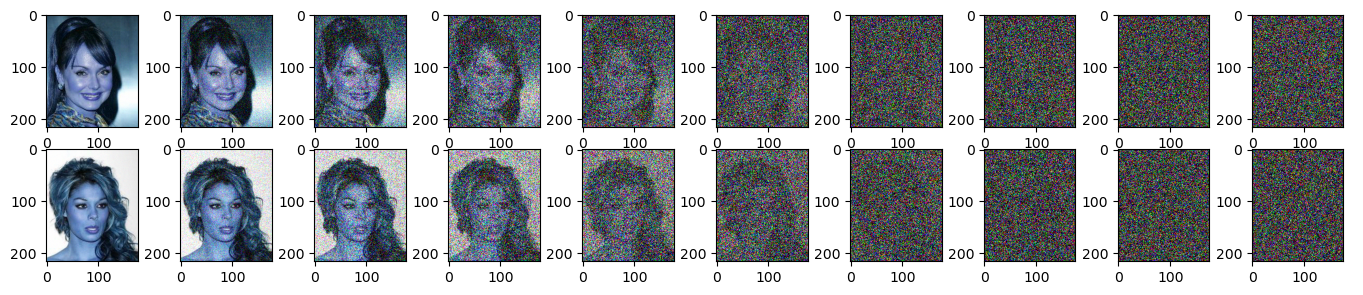

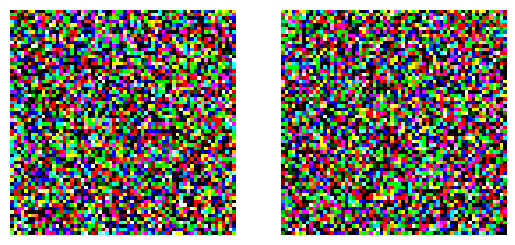

Epoch [1/10], Loss: 1.0035
Epoch [2/10], Loss: 0.9743
Epoch [3/10], Loss: 0.9474
Epoch [4/10], Loss: 0.8872
Epoch [5/10], Loss: 0.8090
Epoch [6/10], Loss: 0.7352
Epoch [7/10], Loss: 0.6762
Epoch [8/10], Loss: 0.5640
Epoch [9/10], Loss: 0.4123
Epoch [10/10], Loss: 0.4507


In [9]:
# DDPM tests
if RUN_TESTS:
    # test forward diffusion on a batch of images
    num_display_steps = 10  # how many progress steps to display
    x_t = x_0 = next(iter(mini_dataloader))
    step_size = T // num_display_steps
    grid_width = num_display_steps  # one column for each progress step
    grid_height = batch_size # one row for each image in the batch
    plt.figure(figsize=(grid_width * 1.7, grid_height * 1.6))
    plt.axis("off")
    x_ts = [x_0]
    for t in range(T):
        x_t, noise = ddpm.forward_diffusion(x_t, t)
        x_ts.append(x_t)
        if t % step_size == 0:
            col = t // step_size + 1
            for i in range(grid_height):
                plt.subplot(grid_height, grid_width, i * grid_width + col)
                plt.imshow(tensor_to_image(x_ts[-1][i]))
    plt.show()

    # test image generation on a batch of images
    shape = (3, 64, 64)
    generated_image = ddpm.generate_images(shape, batch_size)

    for i in range(batch_size):
        plt.subplot(1, batch_size, i + 1)
        plt.axis("off")
        plt.imshow(tensor_to_image(generated_image[i : i + 1]))
    plt.show()

    # test training loop
    ddpm.train(mini_dataloader, epochs=10)

In [10]:
# create model for actual training
T = 200
batch_size = 16
dataloader = DataLoader(all_images, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
schedule = Schedule(beta_1, beta_T, T)
ddpm = DDPM(schedule)

In [ ]:
# train for a while and generate images
for _ in range(10):
    ddpm.train(dataloader, epochs=5, checkpoint_path="models/ddpm_checkpoint.save", checkpoint_interval=3)

    shape = (3, 64, 64)
    generated_image = ddpm.generate_images(shape, batch_size)

    for i in range(batch_size):
        plt.subplot(1, batch_size, i + 1)
        plt.axis("off")
        plt.imshow(tensor_to_image(generated_image[i : i + 1]))
    plt.show()